# 04_2 — Entrenamiento GBDT (HistGradientBoosting)

Revisión del modelo tabular ganador: `HistGradientBoostingClassifier` de scikit-learn.

A diferencia del MLP (04) y el GRU (04_1), el GBDT:
- Predice `p_yes` directamente (no residual)
- No necesita normalización ni embeddings separados
- Usa PCA 16D sobre los embeddings de texto
- Supera al benchmark de mercado en Brier y log-loss sobre el test set

Este notebook **no reentrena** por default. Carga los artefactos guardados en `data/models/hist_gradient_boosting/`.

In [13]:
import sys
import json
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import joblib
from sklearn.metrics import roc_curve, precision_recall_curve, auc

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

from src.config import load_config
from src.model.dataset import PolymarketDataset
from src.model.splits import build_dataset_split
from src.model.calibration import ProbabilityCalibrator

cfg = load_config(str(ROOT / 'config' / 'config.yaml'))
PROCESSED = ROOT / cfg['data']['processed_dir']
SAVE_DIR   = ROOT / 'data' / 'models' / 'hist_gradient_boosting'

RUN_TRAINING = False  # Cambiar a True para reentrenar

print('Root:', ROOT)
print('Processed:', PROCESSED)
print('Save dir:', SAVE_DIR)

Root: /Users/andres/Documents/ITAM/octavo_semestre/mineria_y_analisis/proyecto_polymarket
Processed: /Users/andres/Documents/ITAM/octavo_semestre/mineria_y_analisis/proyecto_polymarket/data/processed
Save dir: /Users/andres/Documents/ITAM/octavo_semestre/mineria_y_analisis/proyecto_polymarket/data/models/hist_gradient_boosting


## 1. Cargar dataset y estadísticas

In [14]:
dataset = PolymarketDataset.from_numpy_dir(str(PROCESSED))

n = len(dataset)
n_pos = int(dataset.labels.sum().item())
n_markets = len(set(dataset.groups.tolist())) if hasattr(dataset, 'groups') else 'N/A'

print(f'Muestras totales : {n:,}')
print(f'Mercados únicos  : {n_markets:,}')
print(f'Positivos (Yes)  : {n_pos:,}  ({100*n_pos/n:.1f}%)')
print(f'Features numéricas: {dataset.numerical.shape[1]}')
print(f'Dim embedding texto: {dataset.text_emb.shape[1]}')

Muestras totales : 39,545
Mercados únicos  : 13,373
Positivos (Yes)  : 12,357  (31.2%)
Features numéricas: 25
Dim embedding texto: 384


## 2. Split temporal agrupado por market_id

El split usa `strategy=temporal_grouped`: los mercados se ordenan por fecha de cierre y se asignan **completos** a cada partición (sin mezclar snapshots del mismo mercado entre train y test).

Estrategia       : temporal_grouped
Train            : 27,683  (31.9% positivos)
Validación       : 5,935  (41.8% positivos)
Test             : 5,927  (17.9% positivos)


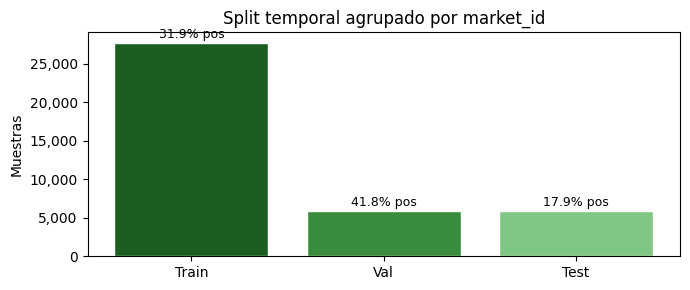

In [15]:
with open(SAVE_DIR / 'run_config.json') as f:
    run_config = json.load(f)

split_cfg = run_config['split']
print(f"Estrategia       : {split_cfg['strategy']}")
print(f"Train            : {split_cfg['train_size']:,}  ({100*split_cfg['class_balance']['train_positive_rate']:.1f}% positivos)")
print(f"Validación       : {split_cfg['val_size']:,}  ({100*split_cfg['class_balance']['val_positive_rate']:.1f}% positivos)")
print(f"Test             : {split_cfg['test_size']:,}  ({100*split_cfg['class_balance']['test_positive_rate']:.1f}% positivos)")

fig, ax = plt.subplots(figsize=(7, 3))
splits = ['Train', 'Val', 'Test']
sizes  = [split_cfg['train_size'], split_cfg['val_size'], split_cfg['test_size']]
pos_rates = [
    split_cfg['class_balance']['train_positive_rate'],
    split_cfg['class_balance']['val_positive_rate'],
    split_cfg['class_balance']['test_positive_rate'],
]
bars = ax.bar(splits, sizes, color=['#1B5E20', '#388E3C', '#81C784'], edgecolor='white')
for bar, pr in zip(bars, pos_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{pr:.1%} pos', ha='center', va='bottom', fontsize=9)
ax.set_title('Split temporal agrupado por market_id', fontsize=12)
ax.set_ylabel('Muestras')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(ROOT / 'figures' / 'gbdt_split_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Búsqueda de hiperparámetros

Se prueban 6 configuraciones sobre el set de validación. El criterio de selección es:
`top_k_pnl > 0 AND beats_market_prob → top_k_pnl → brier → log_loss`

In [16]:
if RUN_TRAINING:
    result = subprocess.run(
        [sys.executable, '-m', 'src.model.train', '--config', str(ROOT / 'config' / 'config.yaml'), '--only', 'gbdt'],
        capture_output=True, text=True, cwd=str(ROOT)
    )
    print(result.stdout[-3000:] if len(result.stdout) > 3000 else result.stdout)
    if result.returncode != 0:
        print('STDERR:', result.stderr[-2000:])

with open(SAVE_DIR / 'training_history.json') as f:
    history = json.load(f)

candidates = history.get('candidates', [])
if candidates:
    rows = []
    for i, c in enumerate(candidates):
        params = c.get('model_params', {})
        val    = c.get('validation', {})
        rows.append({
            'Candidato': f"C{i+1}",
            'lr': params.get('learning_rate'),
            'depth': params.get('max_depth'),
            'iters': params.get('max_iter'),
            'min_leaf': params.get('min_samples_leaf'),
            'l2': params.get('l2_regularization'),
            'val_brier': val.get('brier'),
            'val_logloss': val.get('log_loss'),
            'top_k_hit': val.get('top_k_hit_rate'),
            'top_k_pnl': val.get('top_k_avg_realized_pnl'),
        })
    df_hp = pd.DataFrame(rows)
    # Marcar el mejor
    best_brier = df_hp['val_brier'].min()
    df_hp['selected'] = df_hp['val_brier'] == best_brier

    best_lr   = run_config['model']['learning_rate']
    best_depth = run_config['model']['max_depth']
    print(f'Modelo seleccionado: lr={best_lr}, depth={best_depth}')
    display(df_hp.style.format({
        'val_brier': '{:.4f}',
        'val_logloss': '{:.4f}',
        'top_k_hit': '{:.0%}',
        'top_k_pnl': '{:.3f}',
    }).apply(lambda x: ['background-color: #c8e6c9' if v else '' for v in df_hp['selected']], axis=0))
else:
    print('No hay histórico de candidatos (modelo entrenado en modo directo).')
    print(f"Config guardada: lr={run_config['model']['learning_rate']}, depth={run_config['model']['max_depth']}")

Modelo seleccionado: lr=0.07, depth=6


,Candidato,lr,depth,iters,min_leaf,l2,val_brier,val_logloss,top_k_hit,top_k_pnl,selected
0,C1,0.030000,4,400,30,0.000000,0.0960,0.2751,65%,0.292,False
1,C2,0.030000,6,500,20,0.000000,0.0960,0.2755,65%,0.190,False
2,C3,0.050000,6,300,40,0.100000,0.0952,0.2732,80%,0.350,True
3,C4,0.050000,8,400,20,0.000000,0.0978,0.2805,50%,0.137,False
4,C5,0.070000,6,250,50,0.200000,0.0967,0.2770,85%,0.438,False
5,C6,0.100000,4,250,40,0.100000,0.0969,0.2774,75%,0.294,False


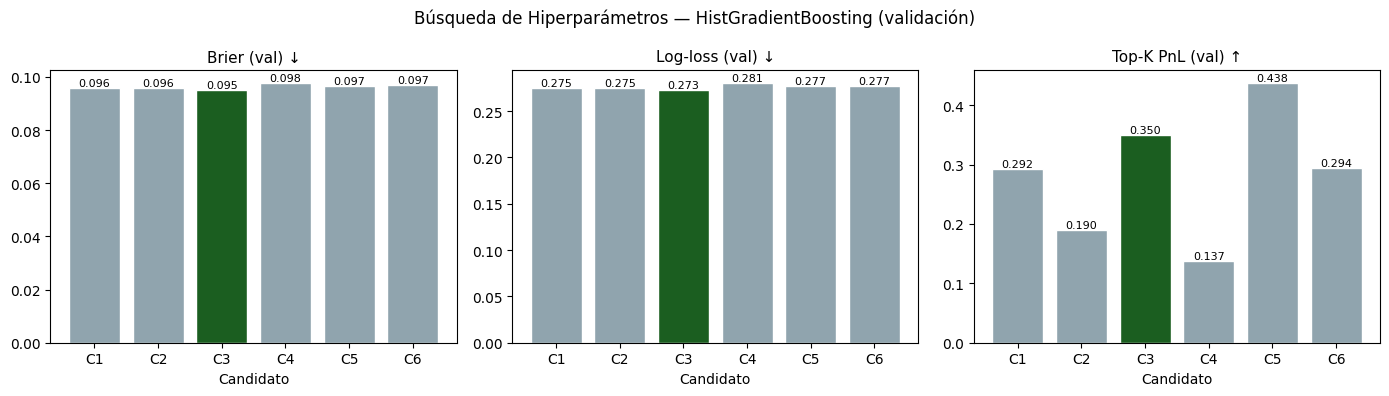

In [17]:
# Visualizar la búsqueda de HP si hay candidatos
if candidates:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    metric_pairs = [
        ('val_brier', 'Brier (val) ↓'),
        ('val_logloss', 'Log-loss (val) ↓'),
        ('top_k_pnl', 'Top-K PnL (val) ↑'),
    ]
    for ax, (col, label) in zip(axes, metric_pairs):
        colors = ['#1B5E20' if s else '#90A4AE' for s in df_hp['selected']]
        ax.bar(df_hp['Candidato'], df_hp[col], color=colors, edgecolor='white')
        ax.set_title(label, fontsize=11)
        ax.set_xlabel('Candidato')
        for bar, val in zip(ax.patches, df_hp[col]):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                    f'{val:.3f}', ha='center', va='bottom', fontsize=8)

    fig.suptitle('Búsqueda de Hiperparámetros — HistGradientBoosting (validación)', fontsize=12)
    plt.tight_layout()
    plt.savefig(ROOT / 'figures' / 'gbdt_hp_search.png', dpi=150, bbox_inches='tight')
    plt.show()

## 4. Calibración de probabilidades

Se comparan tres métodos: identity (sin calibrar), Platt scaling, e isotonic regression. Se selecciona el que minimiza Brier en validación dentro de una tolerancia de 0.5%.

In [18]:
cal_info = run_config.get('calibration', {})
selected_cal = cal_info.get('selected', 'identity')
candidates_cal = cal_info.get('candidates', {})

print(f'Calibración seleccionada: {selected_cal}')
print()

if candidates_cal:
    cal_rows = []
    for name, metrics in candidates_cal.items():
        cal_rows.append({
            'Método': name,
            'Brier (val)': metrics.get('brier'),
            'Log-loss (val)': metrics.get('log_loss'),
            'ECE (val)': metrics.get('ece'),
            'selected': name == selected_cal,
        })
    df_cal = pd.DataFrame(cal_rows)
    display(df_cal.drop('selected', axis=1).style.format({
        'Brier (val)': '{:.5f}',
        'Log-loss (val)': '{:.5f}',
        'ECE (val)': '{:.5f}',
    }).apply(lambda x: ['background-color: #c8e6c9' if df_cal['selected'].iloc[i] else '' for i in range(len(df_cal))], axis=0))

Calibración seleccionada: identity



,Método,Brier (val),Log-loss (val),ECE (val)
0,identity,0.09668,0.27697,0.02120
1,platt,0.10145,0.31080,0.05428
2,isotonic,0.09390,0.26839,0.00000


## 5. Métricas en test: GBDT vs Mercado

El benchmark es el propio mercado (`price_yes`). Un modelo útil debe superar al mercado en al menos Brier o log-loss.

In [19]:
with open(SAVE_DIR / 'test_metrics.json') as f:
    test_metrics = json.load(f)

tm  = test_metrics['test']
vm  = test_metrics['validation']
beaten = test_metrics.get('market_baseline_beaten', {})

raw   = tm['raw_metrics']
mkt   = tm['market_baseline_metrics']
ev    = tm['ev_metrics']

summary = pd.DataFrame([
    {'Métrica': 'Brier ↓',    'GBDT': raw['brier'],    'Mercado': mkt['brier'],    'Gana GBDT': beaten.get('brier', False)},
    {'Métrica': 'Log-loss ↓', 'GBDT': raw['log_loss'], 'Mercado': mkt['log_loss'], 'Gana GBDT': beaten.get('log_loss', False)},
    {'Métrica': 'ROC-AUC ↑',  'GBDT': raw['roc_auc'],  'Mercado': mkt['roc_auc'],  'Gana GBDT': raw['roc_auc'] >= mkt['roc_auc']},
    {'Métrica': 'PR-AUC ↑',   'GBDT': raw['pr_auc'],   'Mercado': mkt['pr_auc'],   'Gana GBDT': raw['pr_auc'] >= mkt['pr_auc']},
    {'Métrica': 'ECE ↓',      'GBDT': raw['ece'],       'Mercado': mkt['ece'],       'Gana GBDT': raw['ece'] <= mkt['ece']},
])

display(summary.style.format({'GBDT': '{:.5f}', 'Mercado': '{:.5f}'}).apply(
    lambda x: ['background-color: #c8e6c9' if v else 'background-color: #ffcdd2' for v in summary['Gana GBDT']], axis=0
))

print(f"\nTop-K (K=100) hit rate    : {ev.get('top_k_hit_rate', 'N/A')}")
print(f"Top-K avg realized PnL    : {ev.get('top_k_avg_realized_pnl', 'N/A'):.4f}")
print(f"Top-K avg predicted EV    : {ev.get('top_k_avg_predicted_ev', 'N/A'):.4f}")

,Métrica,GBDT,Mercado,Gana GBDT
0,Brier ↓,0.00459,0.00618,True
1,Log-loss ↓,0.01770,0.02210,True
2,ROC-AUC ↑,0.99972,0.99996,False
3,PR-AUC ↑,0.99877,0.99984,False
4,ECE ↓,0.00762,0.01483,True



Top-K (K=100) hit rate    : 0.77
Top-K avg realized PnL    : 0.1102
Top-K avg predicted EV    : 0.0899


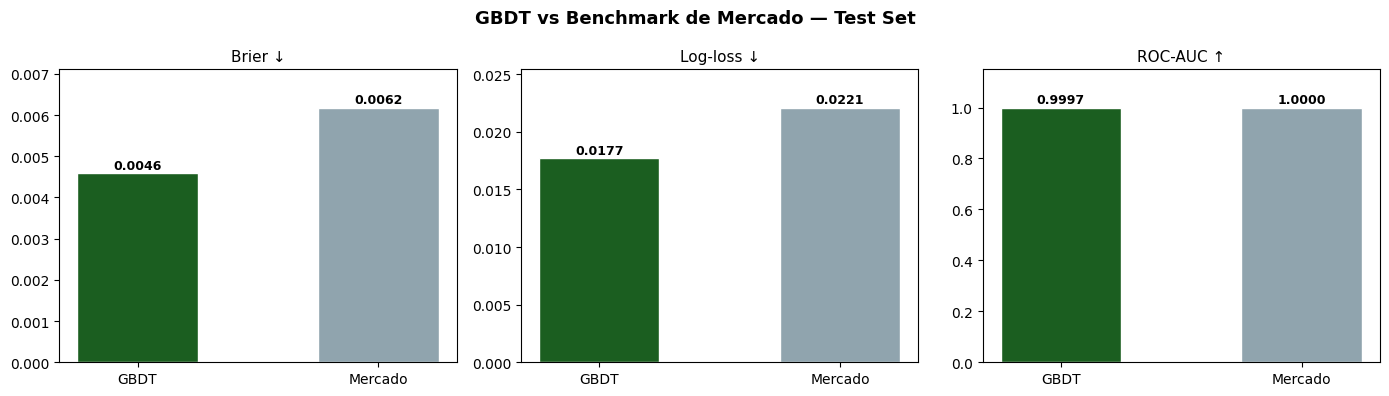

In [20]:
# Barras comparativas: GBDT vs mercado
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

comparisons = [
    ('Brier ↓', raw['brier'], mkt['brier']),
    ('Log-loss ↓', raw['log_loss'], mkt['log_loss']),
    ('ROC-AUC ↑', raw['roc_auc'], mkt['roc_auc']),
]
for ax, (label, gbdt_val, mkt_val) in zip(axes, comparisons):
    bars = ax.bar(['GBDT', 'Mercado'], [gbdt_val, mkt_val],
                  color=['#1B5E20', '#90A4AE'], edgecolor='white', width=0.5)
    for bar, v in zip(bars, [gbdt_val, mkt_val]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.005,
                f'{v:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(label, fontsize=11)
    ax.set_ylim(0, max(gbdt_val, mkt_val) * 1.15)

fig.suptitle('GBDT vs Benchmark de Mercado — Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(ROOT / 'figures' / 'gbdt_vs_market_test.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Curvas ROC y Precision-Recall

Se reconstruyen las predicciones del test set para generar las curvas.

In [21]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import OneHotEncoder

training_cfg = cfg.get('training', {})
seed = int(training_cfg.get('seed', 42))
val_split = float(training_cfg.get('val_split', 0.15))
test_split = float(training_cfg.get('test_split', 0.15))

split = build_dataset_split(
    n_samples=len(dataset),
    labels=dataset.labels.numpy(),
    timestamps=dataset.timestamps,
    groups=dataset.groups,
    val_split=val_split,
    test_split=test_split,
    strategy='temporal_grouped',
    seed=seed,
)
test_idx = np.asarray(split.test_indices, dtype=np.int64)

model_obj  = joblib.load(SAVE_DIR / 'gbdt_model.pkl')
cat_enc    = joblib.load(SAVE_DIR / 'category_encoder.pkl')
text_pca   = joblib.load(SAVE_DIR / 'text_pca.pkl')

numerical = dataset.numerical.numpy()
categories = dataset.categories.numpy()
text_embs  = dataset.text_emb.numpy()
labels_all = dataset.labels.numpy()

cat_feat  = cat_enc.transform(categories[test_idx].reshape(-1, 1))
text_feat = text_pca.transform(text_embs[test_idx])
X_test = np.concatenate([numerical[test_idx], cat_feat, text_feat], axis=1).astype(np.float32)

y_test  = labels_all[test_idx]
y_score = model_obj.predict_proba(X_test)[:, 1]
mkt_prices = np.asarray(dataset.snapshot_prices)[test_idx]

print(f'Test samples: {len(y_test):,}  |  Positivos: {y_test.sum():,}  ({y_test.mean():.1%})')

Test samples: 5,927  |  Positivos: 1,058.0  (17.9%)


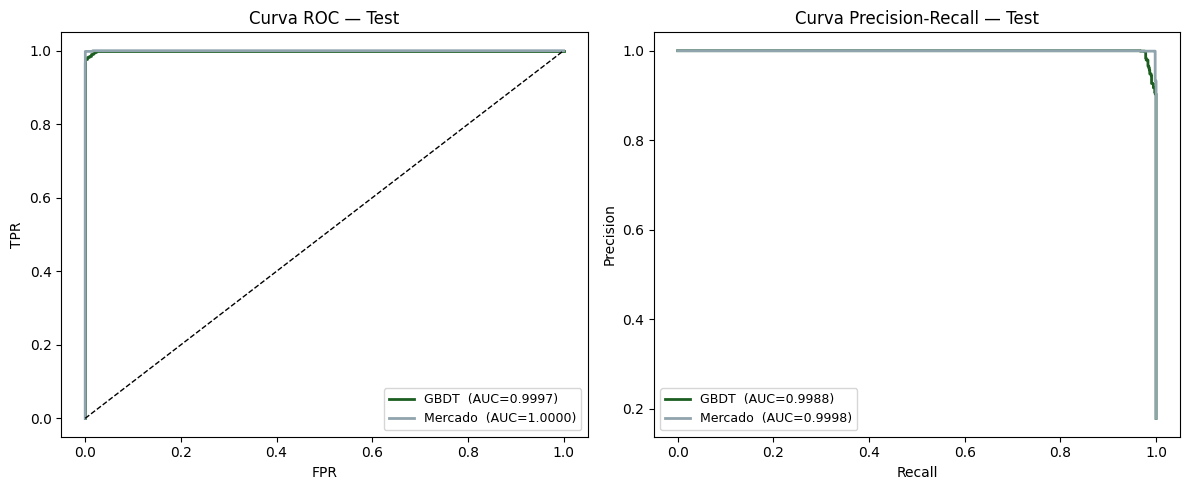

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC
ax = axes[0]
for scores, label, color in [
    (y_score,    'GBDT',    '#1B5E20'),
    (mkt_prices, 'Mercado', '#90A4AE'),
]:
    fpr, tpr, _ = roc_curve(y_test, scores)
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'{label}  (AUC={roc_auc_val:.4f})', color=color, lw=2)
ax.plot([0,1],[0,1], 'k--', lw=1)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('Curva ROC — Test')
ax.legend(fontsize=9)

# PR
ax = axes[1]
for scores, label, color in [
    (y_score,    'GBDT',    '#1B5E20'),
    (mkt_prices, 'Mercado', '#90A4AE'),
]:
    prec, rec, _ = precision_recall_curve(y_test, scores)
    pr_auc_val = auc(rec, prec)
    ax.plot(rec, prec, label=f'{label}  (AUC={pr_auc_val:.4f})', color=color, lw=2)
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Curva Precision-Recall — Test')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(ROOT / 'figures' / 'gbdt_roc_pr.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Distribución de scores en test

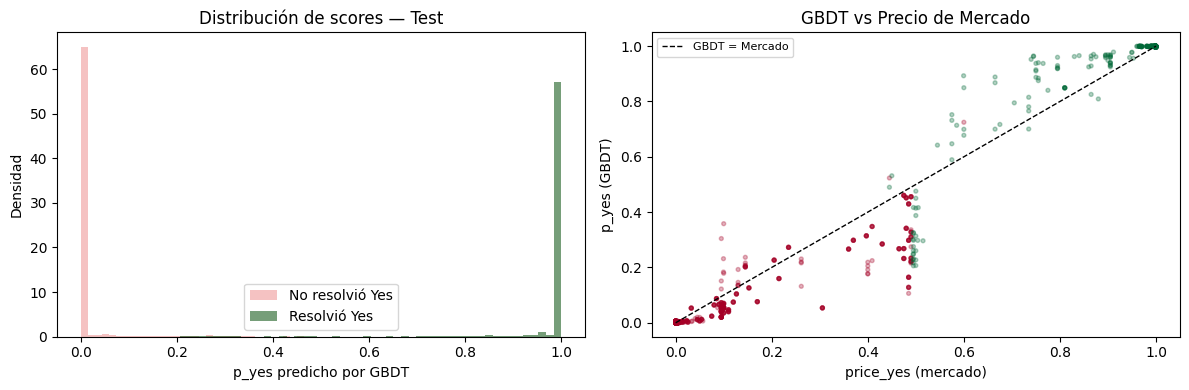

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(y_score[y_test == 0], bins=50, alpha=0.6, label='No resolvió Yes', color='#EF9A9A', density=True)
ax.hist(y_score[y_test == 1], bins=50, alpha=0.6, label='Resolvió Yes', color='#1B5E20', density=True)
ax.set_xlabel('p_yes predicho por GBDT')
ax.set_ylabel('Densidad')
ax.set_title('Distribución de scores — Test')
ax.legend()

ax = axes[1]
ax.scatter(mkt_prices, y_score, c=y_test, cmap='RdYlGn', alpha=0.3, s=8)
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='GBDT = Mercado')
ax.set_xlabel('price_yes (mercado)')
ax.set_ylabel('p_yes (GBDT)')
ax.set_title('GBDT vs Precio de Mercado')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(ROOT / 'figures' / 'gbdt_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Importancia de features

`HistGradientBoostingClassifier` no expone `feature_importances_`; usamos `permutation_importance` sobre test y agregamos categoría/texto por bloque.

Permutation importance sobre test (scoring=ROC-AUC).


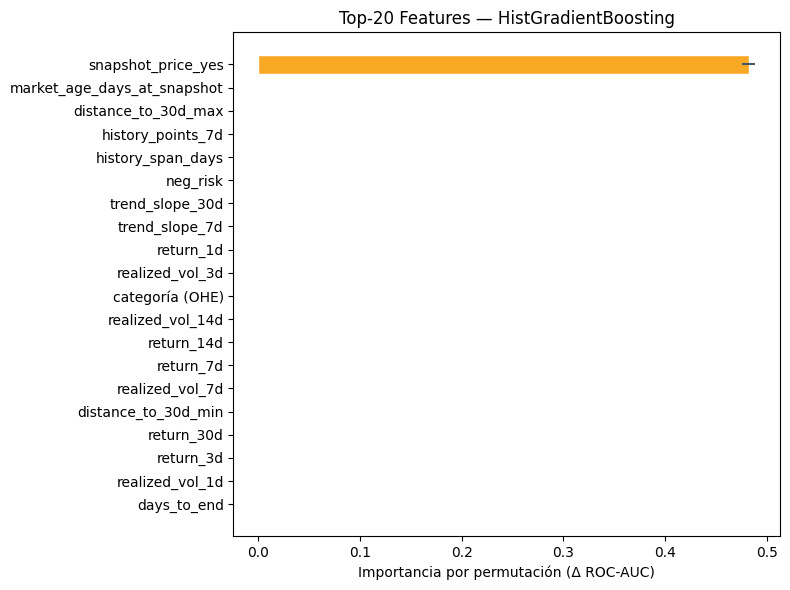

In [24]:
feature_names_num = list(cfg.get('features', {}).get('tabular_feature_names', [
    'snapshot_price_yes', 'days_to_end', 'market_age_days_at_snapshot',
    'days_since_last_trade',
    'history_points_1d', 'history_points_3d', 'history_points_7d', 'history_points_30d',
    'history_span_days',
    'return_1d', 'return_3d', 'return_7d', 'return_14d', 'return_30d',
    'realized_vol_1d', 'realized_vol_3d', 'realized_vol_7d', 'realized_vol_14d', 'realized_vol_30d',
    'trend_slope_7d', 'trend_slope_30d',
    'price_percentile_30d', 'distance_to_30d_min', 'distance_to_30d_max',
    'neg_risk',
]))

from sklearn.inspection import permutation_importance

n_num = len(feature_names_num)
n_cat = cat_enc.transform(categories[:1].reshape(-1,1)).shape[1]
n_pca = text_pca.n_components_

perm = permutation_importance(
    model_obj,
    X_test,
    y_test,
    scoring='roc_auc',
    n_repeats=5,
    random_state=seed,
    n_jobs=1,
)

importances = perm.importances_mean
stds = perm.importances_std

# Agrupar categoría OHE y texto PCA para mantener el gráfico compacto.
imp_num = importances[:n_num]
std_num = stds[:n_num]
imp_cat = importances[n_num:n_num+n_cat].sum()
std_cat = np.sqrt((stds[n_num:n_num+n_cat] ** 2).sum())
imp_pca = importances[n_num+n_cat:].sum()
std_pca = np.sqrt((stds[n_num+n_cat:] ** 2).sum())

all_names = feature_names_num + ['categoría (OHE)', f'texto (PCA {n_pca}D)']
all_imps  = list(imp_num) + [imp_cat, imp_pca]
all_stds  = list(std_num) + [std_cat, std_pca]

df_imp = pd.DataFrame({'feature': all_names, 'importance': all_imps, 'std': all_stds})
df_imp = df_imp.sort_values('importance', ascending=True).tail(20)

print('Permutation importance sobre test (scoring=ROC-AUC).')

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#F9A825' if n in ['snapshot_price_yes', 'neg_risk'] else '#388E3C' for n in df_imp['feature']]
ax.barh(df_imp['feature'], df_imp['importance'], xerr=df_imp['std'], color=colors, edgecolor='white', ecolor='#455A64')
ax.set_xlabel('Importancia por permutación (Δ ROC-AUC)')
ax.set_title('Top-20 Features — HistGradientBoosting', fontsize=12)
plt.tight_layout()
plt.savefig(ROOT / 'figures' / 'gbdt_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Análisis económico: EV y Top-K por horizonte

In [25]:
by_horizon = tm.get('by_horizon', {})

bucket_rows = []
for bucket_name, bucket_data in by_horizon.items():
    prob_m = bucket_data.get('probability_metrics', {})
    mkt_m  = bucket_data.get('market_baseline_metrics', {})
    ev_m   = bucket_data.get('ev_metrics', {})
    bucket_rows.append({
        'Horizonte': bucket_name.replace('_', ' '),
        'n': bucket_data.get('count', 0),
        'GBDT Brier': prob_m.get('brier'),
        'Mkt Brier': mkt_m.get('brier'),
        'GBDT ROC-AUC': prob_m.get('roc_auc'),
        'Top-K hit rate': ev_m.get('top_k_hit_rate'),
        'Top-K PnL': ev_m.get('top_k_avg_realized_pnl'),
    })

df_bkt = pd.DataFrame(bucket_rows)
display(df_bkt.style.format({
    'GBDT Brier': '{:.4f}',
    'Mkt Brier': '{:.4f}',
    'GBDT ROC-AUC': '{:.4f}',
    'Top-K hit rate': '{:.0%}',
    'Top-K PnL': '{:.3f}',
}))

,Horizonte,n,GBDT Brier,Mkt Brier,GBDT ROC-AUC,Top-K hit rate,Top-K PnL
0,short 1 3d,2380,0.0036,0.0052,0.9998,39%,0.011
1,medium 4 14d,2380,0.0034,0.0052,0.9998,40%,0.014
2,long 15plus,1167,0.0089,0.0101,0.9991,62%,0.083


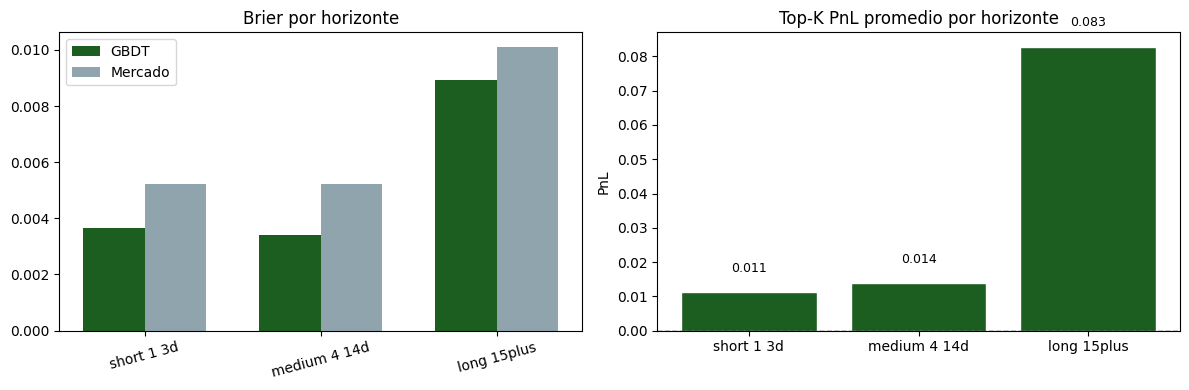

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
x = np.arange(len(df_bkt))
w = 0.35
ax.bar(x - w/2, df_bkt['GBDT Brier'], w, label='GBDT', color='#1B5E20')
ax.bar(x + w/2, df_bkt['Mkt Brier'], w, label='Mercado', color='#90A4AE')
ax.set_xticks(x)
ax.set_xticklabels(df_bkt['Horizonte'], rotation=15)
ax.set_title('Brier por horizonte')
ax.legend()

ax = axes[1]
colors_pnl = ['#1B5E20' if v > 0 else '#EF9A9A' for v in df_bkt['Top-K PnL']]
ax.bar(df_bkt['Horizonte'], df_bkt['Top-K PnL'], color=colors_pnl, edgecolor='white')
ax.axhline(0, color='black', lw=1, ls='--')
ax.set_title('Top-K PnL promedio por horizonte')
ax.set_ylabel('PnL')
for bar, val in zip(ax.patches, df_bkt['Top-K PnL']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(ROOT / 'figures' / 'gbdt_by_horizon.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Resumen final

In [27]:
print('=== HistGradientBoosting — Resumen ===')
print(f"  Modelo: lr={run_config['model']['learning_rate']}, depth={run_config['model']['max_depth']}, "
      f"iters={run_config['model']['max_iter']}")
print(f"  Calibración: {run_config['calibration']['selected']}")
print()
print('  --- Test metrics ---')
print(f"  Brier GBDT:    {raw['brier']:.5f}  |  Mercado: {mkt['brier']:.5f}  {'✓ GANA' if beaten.get('brier') else '✗ pierde'}")
print(f"  Log-loss GBDT: {raw['log_loss']:.5f}  |  Mercado: {mkt['log_loss']:.5f}  {'✓ GANA' if beaten.get('log_loss') else '✗ pierde'}")
print(f"  ROC-AUC:       {raw['roc_auc']:.5f}")
print()
print(f"  Top-{ev.get('top_k', 'K')} hit rate  : {ev.get('top_k_hit_rate', 'N/A')}")
print(f"  Top-{ev.get('top_k', 'K')} avg PnL  : {ev.get('top_k_avg_realized_pnl', 'N/A'):.4f}")
print()
print('Figuras generadas:')
for fig_name in ['gbdt_split_overview', 'gbdt_hp_search', 'gbdt_vs_market_test',
                 'gbdt_roc_pr', 'gbdt_score_distribution', 'gbdt_feature_importance', 'gbdt_by_horizon']:
    p = ROOT / 'figures' / f'{fig_name}.png'
    print(f"  {'✓' if p.exists() else '?'} figures/{fig_name}.png")

=== HistGradientBoosting — Resumen ===
  Modelo: lr=0.07, depth=6, iters=250
  Calibración: identity

  --- Test metrics ---
  Brier GBDT:    0.00459  |  Mercado: 0.00618  ✓ GANA
  Log-loss GBDT: 0.01770  |  Mercado: 0.02210  ✓ GANA
  ROC-AUC:       0.99972

  Top-100 hit rate  : 0.77
  Top-100 avg PnL  : 0.1102

Figuras generadas:
  ✓ figures/gbdt_split_overview.png
  ✓ figures/gbdt_hp_search.png
  ✓ figures/gbdt_vs_market_test.png
  ✓ figures/gbdt_roc_pr.png
  ✓ figures/gbdt_score_distribution.png
  ✓ figures/gbdt_feature_importance.png
  ✓ figures/gbdt_by_horizon.png
